In [1]:
import os
from dotenv import load_dotenv
from shapely.geometry import box
import geopandas as gpd

load_dotenv()

True

In [25]:
guppd_path = os.getenv("GUPPD_PATH")
guppd_gdf = gpd.read_file(guppd_path, layer="urbanspatial_guppd_v1_polygons")
guppd_gdf.sort_values(by="GHSPOP_R23_2025", inplace=True)
guppd_gdf = guppd_gdf[guppd_gdf["GHSPOP_R23_2025"] > 1e6]
guppd_gdf.reset_index(drop=True, inplace=True)
guppd_gdf

,SMOD_LEVEL,SMOD_ID,ISO,CNTRY_NAME,JRC_NAME_MAIN,JRC_NAME_LIST,CIESIN_NAME,CIESIN_NAME_TL,AREA_SQKM,AREA_SQM,...,GHSPOP_R23_1990,GHSPOP_R23_1995,GHSPOP_R23_2000,GHSPOP_R23_2005,GHSPOP_R23_2010,GHSPOP_R23_2015,GHSPOP_R23_2020,GHSPOP_R23_2025,GHSPOP_R23_2030,geometry
0,30,30_7952,IND,India,Begusarai,Begusarai,Begusarai,Begusarai,133.431790,1.334318e+08,...,5.016449e+05,5.727628e+05,6.484238e+05,7.319039e+05,8.126995e+05,8.886113e+05,9.497092e+05,1.001412e+06,1.055053e+06,"MULTIPOLYGON (((85.97254 25.50149, 85.96134 25..."
1,30,30_10027,NGA,Nigeria,Okene,Okene,Nagazi,Nagazi,116.243686,1.162437e+08,...,4.324249e+05,5.793804e+05,7.670834e+05,6.870290e+05,7.380226e+05,8.264633e+05,9.039863e+05,1.001606e+06,1.112628e+06,"MULTIPOLYGON (((6.24023 7.61911, 6.24015 7.611..."
2,30,30_9456,MEX,Mexico,San Luis Potosí,San Luis Potosí,San Luis Potosí,San Luis Potosí,165.203851,1.652039e+08,...,7.019454e+05,7.757979e+05,8.531549e+05,9.100077e+05,9.697752e+05,1.011189e+06,9.840875e+05,1.002011e+06,1.014638e+06,"MULTIPOLYGON (((-100.99013 22.22097, -100.9864..."
3,30,30_9798,MWI,Malawi,Lilongwe,Lilongwe; Lilongwe,Lilongwe,Lilongwe,126.248199,1.262482e+08,...,2.205394e+05,2.940492e+05,3.809043e+05,4.671543e+05,5.752995e+05,7.045286e+05,8.327539e+05,1.002138e+06,1.218928e+06,"MULTIPOLYGON (((33.74672 -13.8657, 33.74819 -1..."
4,30,30_6780,IND,India,Alappuzha,Alappuzha; Cherthala,Alappuzha,Alappuzha,192.772010,1.927720e+08,...,7.880413e+05,8.315526e+05,8.338752e+05,8.439749e+05,8.234079e+05,8.627168e+05,9.426587e+05,1.003910e+06,1.053972e+06,"MULTIPOLYGON (((76.31673 9.77191, 76.30641 9.6..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510,30,30_544,BGD,Bangladesh,Dhaka,Dhaka; Dhamrai; Narayanganj; Munshiganj,ঢাকা,Dhaka,3233.307916,3.233308e+09,...,1.017859e+07,1.235137e+07,1.481327e+07,1.748306e+07,2.034622e+07,2.365933e+07,2.699576e+07,3.089791e+07,3.457912e+07,"MULTIPOLYGON (((90.37027 24.35136, 90.35545 24..."
511,30,30_5829,IND,India,Delhi [New Delhi],Delhi; Gurugram; Ghaziabad; New Delhi; Faridab...,Delhi,Delhi,2465.007566,2.465008e+09,...,1.284926e+07,1.577686e+07,1.931753e+07,2.193707e+07,2.455794e+07,2.737469e+07,3.032578e+07,3.241051e+07,3.421294e+07,"MULTIPOLYGON (((77.07093 29.08021, 77.06698 29..."
512,30,30_9071,JPN,Japan,Tokyo,Tokyo; Yokohama; Kawasaki; Saitama; Chiba; Set...,豊島区,Fēng Dǎo Qū,5306.534377,5.306534e+09,...,2.924315e+07,2.962962e+07,3.070216e+07,3.168504e+07,3.274152e+07,3.329779e+07,3.355138e+07,3.325842e+07,3.289596e+07,"MULTIPOLYGON (((139.36174 36.18783, 139.352 36..."
513,30,30_5056,IDN,Indonesia,Jakarta,Jakarta; Bekasi; Tangerang; Depok; South Tange...,Cianjur,Cianjur,4976.265945,4.976266e+09,...,2.134360e+07,2.370278e+07,2.653063e+07,2.965855e+07,3.311241e+07,3.630007e+07,3.899680e+07,4.132239e+07,4.357476e+07,"MULTIPOLYGON (((106.66569 -6.01338, 106.66667 ..."


In [17]:
big_cities_gdf = guppd_gdf.copy()
big_cities_gdf['geometry'] = big_cities_gdf.geometry.apply(lambda x: box(*x.bounds))
big_cities_gdf.to_file(INPUT_DIR / "NASA" / "GUPPD" / "big_cities_bbox.gpkg", driver="GPKG")

## Filter patches by city

In [10]:
bbox_rxr_gdf = gpd.read_file(os.path.join(os.getenv("SO2SAT_DIR", ), 'patches_reference_rxr.gpkg'))
bbox_rxr_gdf

,patch_id,dataset,LCZ_class,geometry
0,000000,training,6,"POLYGON ((72.96642 33.65667, 72.96642 33.65961..."
1,000001,training,17,"POLYGON ((-73.78031 40.81731, -73.78031 40.820..."
2,000002,training,17,"POLYGON ((-154.65521 -56.31613, -154.65521 -56..."
3,000003,training,2,"POLYGON ((31.28295 29.98253, 31.28295 29.98546..."
4,000004,training,8,"POLYGON ((31.29023 29.92037, 31.29023 29.9233,..."
...,...,...,...,...
400668,024183,testing,14,"POLYGON ((-70.5682 -33.68039, -70.5682 -33.677..."
400669,024184,testing,8,"POLYGON ((113.16117 23.09319, 113.16117 23.096..."
400670,024185,testing,3,"POLYGON ((-122.37642 37.58178, -122.37642 37.5..."
400671,024186,testing,17,"POLYGON ((-122.33301 37.75099, -122.33301 37.7..."


In [114]:
city = "Madrid"
city_filt_gdf = guppd_gdf.copy()[guppd_gdf['JRC_NAME_MAIN'] == city]
city_filt_gdf['geometry'] = city_filt_gdf['geometry'].buffer(.76)
print(city_filt_gdf.bounds)

         minx       miny      maxx       maxy
441 -4.712051  39.451267 -2.669388  41.338875


/tmp/ipykernel_971159/1014485484.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  city_filt_gdf['geometry'] = city_filt_gdf['geometry'].buffer(.76)


In [115]:
patch_filt_gdf = gpd.sjoin(bbox_rxr_gdf, city_filt_gdf, how='inner').reset_index(drop=True)[['patch_id', 'dataset', 'LCZ_class', 'geometry']]
print(len(patch_filt_gdf))
patch_filt_gdf.groupby('LCZ_class').count()

7022


,patch_id,dataset,geometry
LCZ_class,,,
1,15,15,15
2,762,762,762
3,200,200,200
4,169,169,169
5,439,439,439
6,1094,1094,1094
8,728,728,728
9,135,135,135
10,83,83,83


<Axes: >

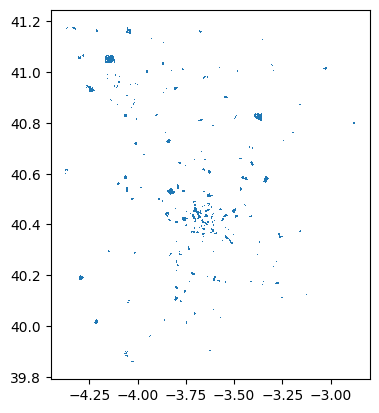

In [116]:
patch_filt_gdf.to_file(os.path.join(os.getenv("SO2SAT_DIR"), f'patches_reference_{city}.gpkg'), driver="GPKG")
patch_filt_gdf.plot()